# 01 — EDA and Data Exploration
## Dataset: Titanic
## Goal: Understand the data before building any model

### What this notebook covers:
- Loading and inspecting the data
- Checking missing values
- Checking class balance
- Understanding distributions
- Finding outliers
- Correlation analysis
- Key findings summary

##1. Import Libraries
Importing all the necessary Libraries for EDA

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries successfully loaded")



Libraries successfully loaded


## 2. Loading the Data
Loading the titanic dataset from the CSV file

In [10]:
df =pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Inspecting Data
Checking shapa, data type and the first few rows

In [18]:
print(f'shape:, {df.shape}')
print(f"Rows: {df.shape[0]}")
print(f"Coloumns: {df.shape[1]}")
print(df.describe())
print()
print(df.info())

shape:, (891, 12)
Rows: 891
Coloumns: 12
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

<class 'pandas.core.frame.DataFrame'>
R

## Missing Values
Checking columns with missing  values and how many

In [12]:
print(df.isnull().sum())
print()
print(df.isnull().sum()/len(df))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64


## 5. Class Balance
Checking how many passengers survived vs did not survive

In [13]:
print(df["Survived"].value_counts())
print()
print(df['Survived'].value_counts(normalize=True)*100)

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


### Visualizing Class Balance

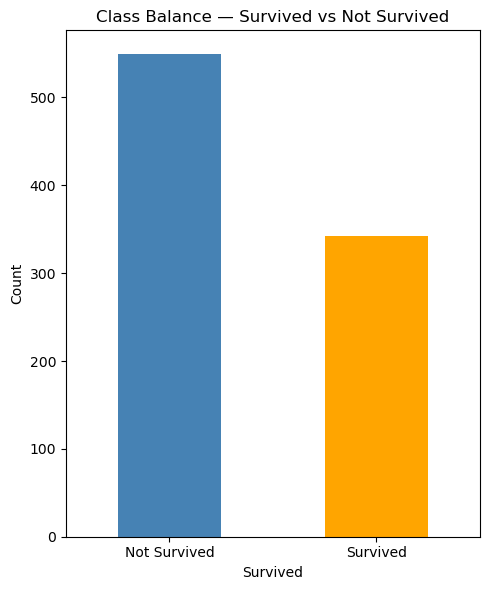

In [14]:
df['Survived'].value_counts().plot(
    kind ='bar',
    color= ['steelblue', 'orange'],
    figsize=(5,6)
)

plt.title('Class Balance — Survived vs Not Survived')
plt.xlabel("Survived")
plt.ylabel('Count')
plt.xticks([0,1],['Not Survived', 'Survived'], rotation =0)
plt.tight_layout()
plt.show()

## Age Distribution
Analyzing the age distibution of passangers

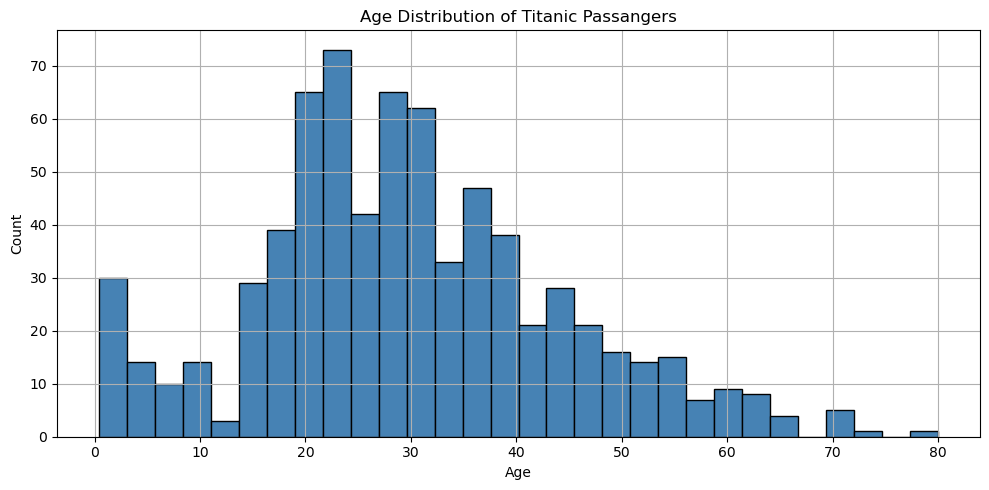


Mean Age: 29.70
Median Age: 28.00
Mode Age: 24.00


In [16]:
plt.figure(figsize=(10,5))
df['Age'].hist(bins=30, color ='steelblue', edgecolor='black')
plt.title("Age Distribution of Titanic Passangers")
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print()
print(f"Mean Age: {df['Age'].mean():.2f}")
print(f"Median Age: {df['Age'].median():.2f}")
print(f"Mode Age: {df['Age'].mode()[0]:.2f}")

## 7. Outliers
Using boxplots to detect outliers in numeric columns.

              Age        Fare       SibSp       Parch
count  714.000000  891.000000  891.000000  891.000000
mean    29.699118   32.204208    0.523008    0.381594
std     14.526497   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     20.125000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     38.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000



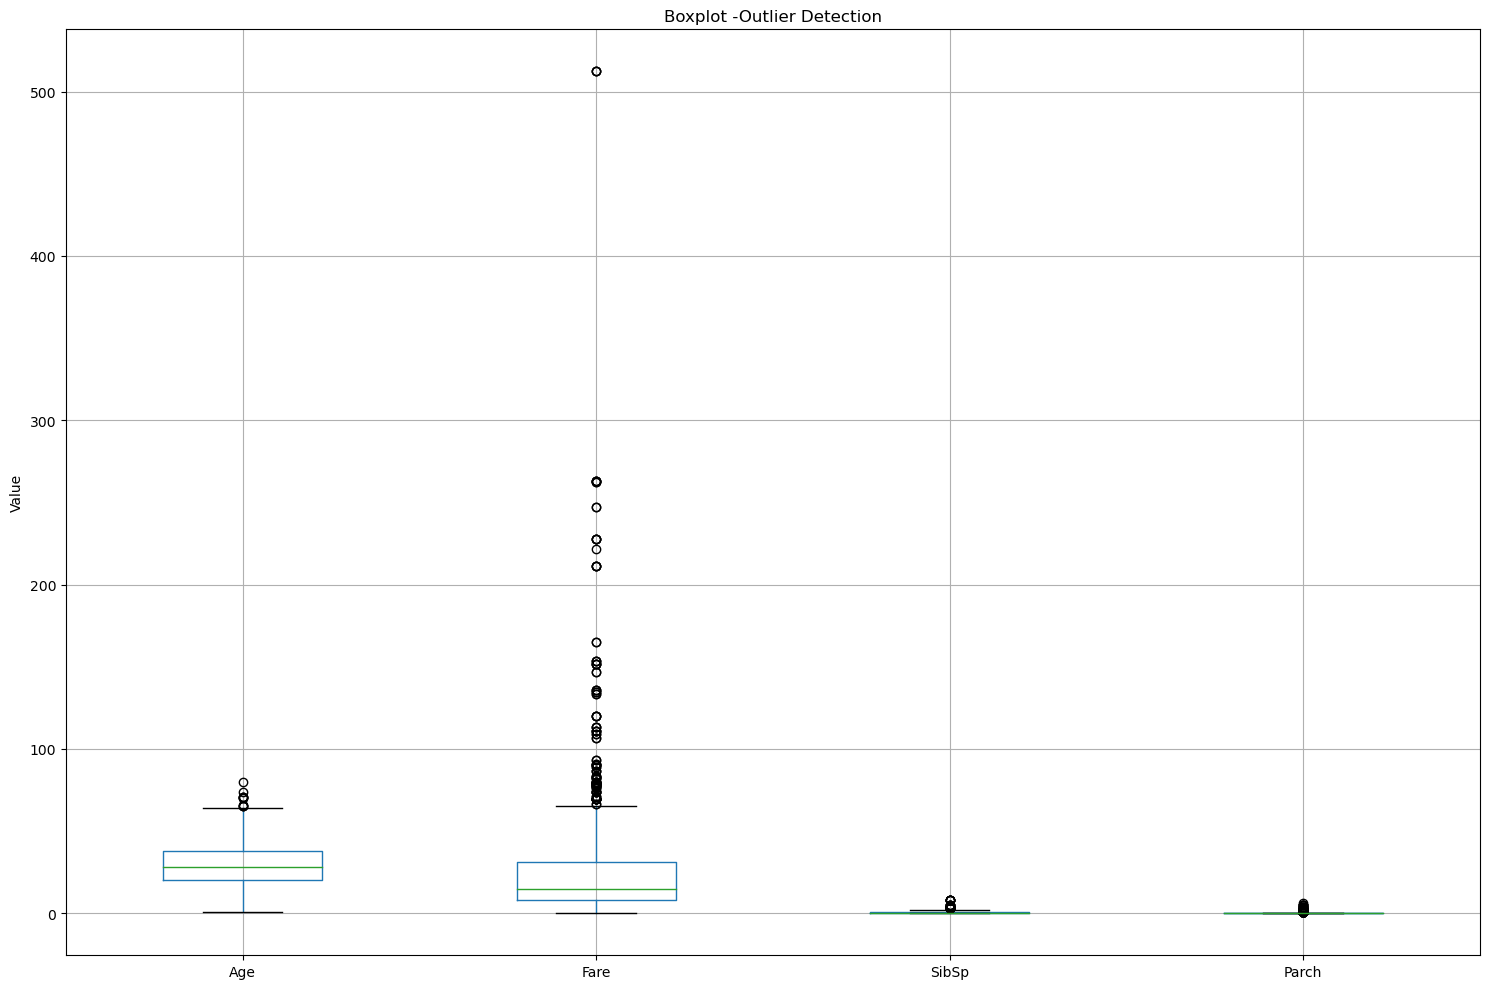

In [22]:
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

print(df[numeric_cols].describe())
print()
plt.figure(figsize=(15,10))
df[numeric_cols].boxplot()
plt.title('Boxplot -Outlier Detection')
plt.ylabel("Value")
plt.tight_layout()
plt.show()




## 8. Correlation Heatmap
Checking relationships between numeric columns.

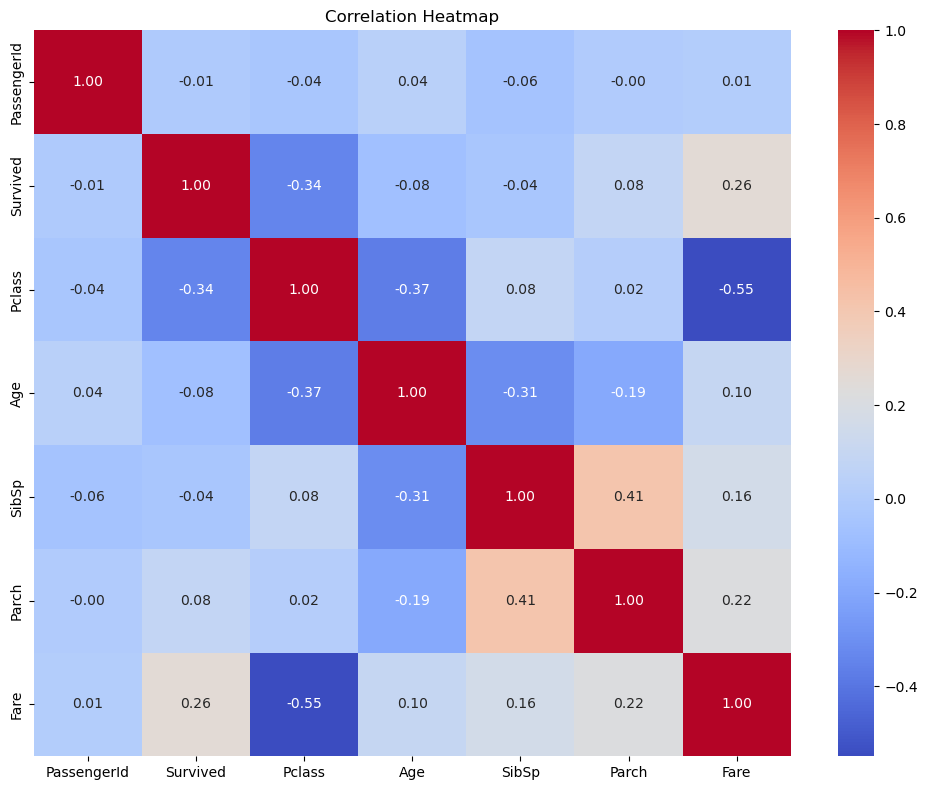

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            fmt='.2f',
            cmap='coolwarm'
            )
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 9. Key Findings Summary

### What I found in this EDA:
### What I found in this EDA:

**Dataset Overview:**
- 891 rows and 12 columns
- 7 numeric columns, 5 categorical columns

**Missing Values:**
- Age: 177 missing values (19.8%)
- Cabin: 687 missing values (77%) — drop this column
- Embarked: 2 missing values — fill with mode

**Class Balance:**
- 61.6% did not survive
- 38.4% survived
- Dataset is imbalanced — use F1 Score not accuracy

**Age Distribution:**
- Most passengers aged 20-30
- Right skewed — fill missing Age with median

**Outliers:**
- Fare has extreme outliers up to £512
- Apply log transformation before modelling

**Correlation:**
- Pclass vs Survived = -0.34 — lower class survived less
- Fare vs Survived = +0.26 — higher fare survived more
- SibSp vs Parch = +0.41 — families travel together

**Next Step:**
- Clean the data
- Handle missing values
- Encode categorical columns
- Build ML model